# Case Técnico — Engenharia de Dados | Itaú

## Objetivo
Investigar por que a satisfação dos clientes de investimentos caiu no último trimestre, identificar os produtos mais afetados e buscar fatores operacionais associados à deterioração.

## Fontes de dados
- `formulario_digital.csv`: respostas de satisfação dos clientes;
- `atendimento_manual.xlsx`: registros de atendimento;
- `extrato_sistema.csv`: indicadores operacionais;
- `dicionario_dados_case.xlsx`: documentação dos campos.

> **Pergunta de negócio:** por que a satisfação caiu no último trimestre e o que pode ser feito a respeito?


In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 1. Carregamento e exploração inicial

Primeiro, as quatro fontes são carregadas e avaliadas quanto a volume, tipos e valores ausentes.

In [32]:
atendimento = pd.read_excel('/content/atendimento_manual.xlsx')
dicionario = pd.read_excel('/content/dicionario_dados_case.xlsx')
extrato = pd.read_csv('/content/extrato_sistema.csv')
formulario = pd.read_csv('/content/formulario_digital.csv')

In [33]:
resumo_fontes = pd.DataFrame({
    'fonte': ['formulario', 'atendimento', 'extrato'],
    'linhas': [len(formulario), len(atendimento), len(extrato)],
    'colunas': [formulario.shape[1], atendimento.shape[1], extrato.shape[1]]
})
resumo_fontes

,fonte,linhas,colunas
0,formulario,1037,10
1,atendimento,272,8
2,extrato,942,7


In [34]:
print('FORMULÁRIO')
formulario.info()
print("ATENDIMENTO")
atendimento.info()
print('EXTRATO')
extrato.info()

FORMULÁRIO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1037 entries, 0 to 1036
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   id_pesquisa           1037 non-null   object
 1   id_cliente            1037 non-null   object
 2   data_resposta         1037 non-null   object
 3   trimestre_ref         1037 non-null   object
 4   segmento_declarado    1037 non-null   object
 5   produto               1037 non-null   object
 6   canal                 1027 non-null   object
 7   tempo_relacionamento  1037 non-null   object
 8   nota_satisfacao       1037 non-null   int64 
 9   comentario            1011 non-null   object
dtypes: int64(1), object(9)
memory usage: 81.1+ KB
ATENDIMENTO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 272 entries, 0 to 271
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   codigo_cli

## 2. Limpeza e padronização dos dados

As fontes usam formatos diferentes para identificadores, produtos e datas. A padronização é necessária antes da integração.

### 2.1 Padronização dos identificadores

No formulário, os clientes aparecem no formato `C00103`; nas demais fontes, o identificador é numérico. Uma nova coluna é criada preservando o dado original.

In [35]:
formulario['id_cliente_padrao'] = (
    formulario['id_cliente']
    .str.replace('C', '', regex=False)
    .astype(int)
)

formulario[['id_cliente', 'id_cliente_padrao']].head()

,id_cliente,id_cliente_padrao
0,C00103,103
1,C00269,269
2,C00229,229
3,C00097,97
4,C00105,105


In [36]:
ids_formulario = set(formulario['id_cliente_padrao'])
ids_extrato = set(extrato['customer_id'])
ids_atendimento = set(atendimento['codigo_cliente'])

print('Clientes únicos no formulário:', formulario['id_cliente_padrao'].nunique())
print('Em comum com o extrato:', len(ids_formulario & ids_extrato))
print('Em comum com o atendimento:', len(ids_formulario & ids_atendimento))

Clientes únicos no formulário: 467
Em comum com o extrato: 448
Em comum com o atendimento: 207


### 2.2 Padronização dos produtos

O mesmo produto aparece com grafias diferentes entre as fontes. Os nomes são normalizados para cinco categorias: **CDB, Tesouro Direto, Fundos, Carteira Administrada e COE**.

#### 2.2.1 Atendimento

In [37]:
mapeamento_atendimento = {
    'cdb': 'CDB',
    'c.d.b.': 'CDB',
    'tesouro': 'Tesouro Direto',
    'tesouro direto': 'Tesouro Direto',
    'carteira administrada': 'Carteira Administrada',
    'carteira adm': 'Carteira Administrada',
    'fundo': 'Fundos',
    'fundos': 'Fundos',
    'fundos de investimento': 'Fundos',
    'coe': 'COE',
    'c.o.e.': 'COE'
}

atendimento['produto_padronizado'] = (
    atendimento['produto_investimento']
    .str.lower()
    .replace(mapeamento_atendimento)
)

atendimento[['produto_investimento', 'produto_padronizado']].value_counts()

,,count
produto_investimento,produto_padronizado,
cdb,CDB,34
C.D.B.,CDB,29
fundos de investimento,Fundos,23
tesouro direto,Tesouro Direto,22
Tesouro,Tesouro Direto,21
Carteira Administrada,Carteira Administrada,20
Fundos,Fundos,20
Fundo,Fundos,18
carteira administrada,Carteira Administrada,18


#### 2.2.2 Extrato

In [38]:
mapeamento_extrato = {
    'PRD_CDB': 'CDB',
    'PRD_TES': 'Tesouro Direto',
    'PRD_FND': 'Fundos',
    'PRD_CAR': 'Carteira Administrada',
    'PRD_COE': 'COE'
}

extrato['produto_padronizado'] = extrato['produto_codigo'].map(mapeamento_extrato)
extrato[['produto_codigo', 'produto_padronizado']].value_counts()

,,count
produto_codigo,produto_padronizado,
PRD_CDB,CDB,258
PRD_TES,Tesouro Direto,231
PRD_FND,Fundos,227
PRD_CAR,Carteira Administrada,167
PRD_COE,COE,59


### 2.3 Tratamento das datas

As colunas de data chegaram como texto. Elas são convertidas para `datetime`. Registros do extrato sem data válida são preservados na base original, mas ficam fora do relacionamento temporal.

In [39]:
formulario['data_resposta'] = pd.to_datetime(
    formulario['data_resposta'], errors='coerce'
)

extrato['survey_datetime'] = pd.to_datetime(
    extrato['survey_datetime'], errors='coerce'
)

print('Datas inválidas no formulário:', formulario['data_resposta'].isna().sum())
print('Datas inválidas no extrato:', extrato['survey_datetime'].isna().sum())

Datas inválidas no formulário: 0
Datas inválidas no extrato: 8


In [40]:
extrato_sem_data = extrato[extrato['survey_datetime'].isna()].copy()
extrato_com_data = extrato[extrato['survey_datetime'].notna()].copy()

print('Extrato com data válida:', len(extrato_com_data))
print('Extrato sem data válida:', len(extrato_sem_data))

Extrato com data válida: 934
Extrato sem data válida: 8


## 3. Integração entre formulário e extrato

Um `merge` apenas pelo cliente multiplicou registros porque um mesmo cliente pode aparecer várias vezes, inclusive no mesmo produto. Para preservar **uma linha por pesquisa**, o relacionamento foi definido por:

- mesmo cliente;
- mesmo produto;
- data mais próxima;
- tolerância máxima de **10 dias**.

A tolerância foi escolhida após observar que a grande maioria dos pares estava concentrada entre 0 e 10 dias, enquanto os poucos casos restantes apresentavam saltos muito maiores.

In [41]:
formulario_ordenado = formulario.sort_values(
    ['data_resposta', 'id_cliente_padrao', 'produto']
).reset_index(drop=True)

extrato_ordenado = extrato_com_data.sort_values(
    ['survey_datetime', 'customer_id', 'produto_padronizado']
).reset_index(drop=True)

In [42]:
dados_match = pd.merge_asof(
    formulario_ordenado,
    extrato_ordenado,
    left_on='data_resposta',
    right_on='survey_datetime',
    left_by=['id_cliente_padrao', 'produto'],
    right_by=['customer_id', 'produto_padronizado'],
    direction='nearest',
    tolerance=pd.Timedelta(days=10)
)

# Diferença temporal entre os registros associados
dados_match['dif_dias'] = (
    dados_match['data_resposta'] - dados_match['survey_datetime']
).abs().dt.days

print('Linhas do formulário:', len(formulario))
print('Linhas após integração:', len(dados_match))

Linhas do formulário: 1037
Linhas após integração: 1037


In [43]:
# Como os nomes podem receber sufixos quando há colunas repetidas,
# identificamos a coluna de customer_id proveniente do extrato.
col_customer_extrato = 'customer_id_y' if 'customer_id_y' in dados_match.columns else 'customer_id'

sem_match = dados_match[col_customer_extrato].isna().sum()
com_match = len(dados_match) - sem_match
cobertura = com_match / len(dados_match)

print('Pesquisas com correspondência:', com_match)
print('Pesquisas sem correspondência:', sem_match)
print(f'Cobertura do relacionamento: {cobertura:.1%}')
print('Diferença em dias dos matches:')
print(dados_match['dif_dias'].describe())

Pesquisas com correspondência: 945
Pesquisas sem correspondência: 92
Cobertura do relacionamento: 91.1%
Diferença em dias dos matches:
count    945.000000
mean       5.190476
std        3.019659
min        0.000000
25%        3.000000
50%        5.000000
75%        8.000000
max       10.000000
Name: dif_dias, dtype: float64


## 4. Onde a satisfação caiu?

A satisfação é analisada por trimestre e produto para identificar onde a deterioração se concentra.

In [44]:
satisfacao_produto_trimestre = (
    formulario
    .groupby(['trimestre_ref', 'produto'])['nota_satisfacao']
    .mean()
    .unstack()
    .round(2)
)

satisfacao_produto_trimestre

produto,CDB,COE,Carteira Administrada,Fundos,Tesouro Direto
trimestre_ref,,,,,
2025T3,8.52,8.77,8.90,8.77,8.83
2025T4,8.72,8.65,8.86,8.97,8.51
2026T1,8.82,8.22,8.37,8.70,9.11
2026T2,8.68,8.63,8.05,8.18,9.08


In [45]:
comparacao_satisfacao = (
    formulario[formulario['trimestre_ref'].isin(['2026T1', '2026T2'])]
    .groupby(['produto', 'trimestre_ref'])['nota_satisfacao']
    .mean()
    .unstack()
)

comparacao_satisfacao['variacao_T2_vs_T1'] = (
    comparacao_satisfacao['2026T2'] - comparacao_satisfacao['2026T1']
)

comparacao_satisfacao.sort_values('variacao_T2_vs_T1').round(2)

trimestre_ref,2026T1,2026T2,variacao_T2_vs_T1
produto,,,
Fundos,8.70,8.18,-0.52
Carteira Administrada,8.37,8.05,-0.32
CDB,8.82,8.68,-0.14
Tesouro Direto,9.11,9.08,-0.03
COE,8.22,8.63,0.41


Os maiores sinais de deterioração no 2026T2 aparecem em **Fundos** e **Carteira Administrada**. A partir daqui, a análise operacional se concentra nesses dois produtos.

## 5. Investigação operacional

Para os produtos mais afetados, são comparados os indicadores do extrato entre 2026T1 e 2026T2: quantidade de reclamações, tempo de resolução e incidência de suitability pendente.

In [46]:
carteira_comparacao = dados_match[
    (dados_match['produto'] == 'Carteira Administrada') &
    (dados_match['trimestre_ref'].isin(['2026T1', '2026T2']))
]

carteira_metricas = carteira_comparacao.groupby('trimestre_ref').agg(
    satisfacao_media=('nota_satisfacao', 'mean'),
    reclamacoes_media=('qtd_reclamacoes_90d', 'mean'),
    tempo_resolucao_medio_h=('tempo_resolucao_horas', 'mean'),
    suitability_pendente=('suitability_pendente', 'mean')
).round(3)

carteira_metricas

,satisfacao_media,reclamacoes_media,tempo_resolucao_medio_h,suitability_pendente
trimestre_ref,,,,
2026T1,8.372,0.297,41.135,0.054
2026T2,8.051,0.627,82.276,0.132


In [47]:
fundos_comparacao = dados_match[
    (dados_match['produto'] == 'Fundos') &
    (dados_match['trimestre_ref'].isin(['2026T1', '2026T2']))
]

fundos_metricas = fundos_comparacao.groupby('trimestre_ref').agg(
    satisfacao_media=('nota_satisfacao', 'mean'),
    reclamacoes_media=('qtd_reclamacoes_90d', 'mean'),
    tempo_resolucao_medio_h=('tempo_resolucao_horas', 'mean'),
    suitability_pendente=('suitability_pendente', 'mean')
).round(3)

fundos_metricas

,satisfacao_media,reclamacoes_media,tempo_resolucao_medio_h,suitability_pendente
trimestre_ref,,,,
2026T1,8.702,0.000,17.183,0.096
2026T2,8.179,0.102,21.938,0.115


In [48]:
satisfacao_produto = (
    dados_match[
        dados_match["trimestre_ref"].isin(["2026T1", "2026T2"])
    ]
    .groupby(["produto", "trimestre_ref"])["nota_satisfacao"]
    .mean()
)
satisfacao_produto

produto                trimestre_ref
CDB                    2026T1           8.818182
                       2026T2           8.676056
COE                    2026T1           8.222222
                       2026T2           8.631579
Carteira Administrada  2026T1           8.372093
                       2026T2           8.051282
Fundos                 2026T1           8.701754
                       2026T2           8.179104
Tesouro Direto         2026T1           9.114754
                       2026T2           9.083333
Name: nota_satisfacao, dtype: float64

In [49]:
satisfacao_grafico["variacao"] = (
    satisfacao_grafico["2026T2"] - satisfacao_grafico["2026T1"]
)

satisfacao_grafico

trimestre_ref,2026T1,2026T2,variacao
produto,,,
CDB,8.818182,8.676056,-0.142125
COE,8.222222,8.631579,0.409357
Carteira Administrada,8.372093,8.051282,-0.320811
Fundos,8.701754,8.179104,-0.522650
Tesouro Direto,9.114754,9.083333,-0.031421


In [50]:
variacao_ordenada = satisfacao_grafico["variacao"].sort_values()

variacao_ordenada

,variacao
produto,
Fundos,-0.522650
Carteira Administrada,-0.320811
CDB,-0.142125
Tesouro Direto,-0.031421
COE,0.409357


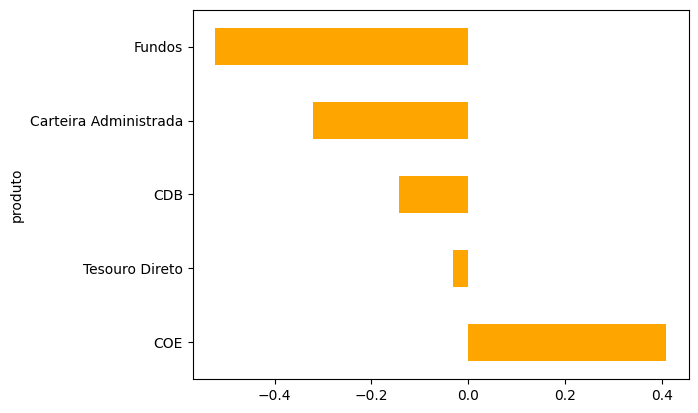

In [51]:
ax = variacao_ordenada.plot(
    kind="barh",
    color="orange"
)
ax.invert_yaxis()
plt.show()

In [52]:
variacao_operacional = (
    (carteira_indicadores.loc["2026T2"] - carteira_indicadores.loc["2026T1"])
    / carteira_indicadores.loc["2026T1"]
) * 100

variacao_operacional

,0
qtd_reclamacoes_90d,110.854817
tempo_resolucao_horas,100.015073
suitability_pendente,144.852941


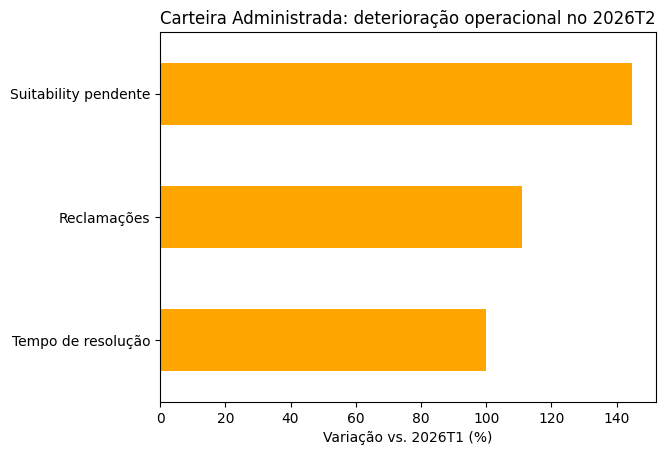

In [53]:
variacao_operacional.index = [
    "Reclamações",
    "Tempo de resolução",
    "Suitability pendente"
]

ax = variacao_operacional.sort_values().plot(
    kind="barh",
    color="orange"
)

ax.set_title("Carteira Administrada: deterioração operacional no 2026T2")
ax.set_xlabel("Variação vs. 2026T1 (%)")
ax.set_ylabel("")

plt.show()

## 6. Principais achados

### Carteira Administrada
Entre 2026T1 e 2026T2, a satisfação caiu de **8,37 para 8,05**. No mesmo período:

- reclamações médias em 90 dias aumentaram de **0,30 para 0,63**;
- tempo médio de resolução aumentou de **41,1 h para 82,3 h**;
- suitability pendente aumentou de **5,4% para 13,2%**.

### Fundos
A satisfação caiu de **8,70 para 8,18**. No mesmo período:

- reclamações médias passaram de **0,00 para 0,10**;
- tempo médio de resolução aumentou de **17,2 h para 21,9 h**;
- suitability pendente aumentou de **9,6% para 11,5%**.

### Interpretação
Os dados indicam que a queda da satisfação no último trimestre está concentrada principalmente em **Fundos e Carteira Administrada**. Em ambos, a redução da satisfação ocorre junto a uma piora de indicadores operacionais. O sinal é especialmente forte em Carteira Administrada.

Esses resultados mostram **associação**, não causalidade comprovada.

## 7. Recomendações

Com base nos padrões observados:

1. **Priorizar Carteira Administrada**, investigando gargalos que elevaram o tempo de resolução e a incidência de reclamações no 2026T2.
2. **Acompanhar Fundos**, onde a satisfação teve a maior queda, mesmo com deterioração operacional mais moderada.
3. **Criar monitoramento recorrente por produto**, acompanhando satisfação, reclamações, tempo de resolução e suitability em conjunto.
4. **Atuar preventivamente em pendências de suitability**, especialmente em Carteira Administrada, antes que elas evoluam para contatos e reclamações.


## 8. Limitações da análise

- O relacionamento principal entre formulário e extrato foi construído por **cliente + produto + proximidade temporal de até 10 dias**; portanto, trata-se de uma regra de associação e não de uma chave transacional explícita.
- Cerca de **91% das pesquisas** encontraram correspondência válida com o extrato usando essa regra.
- Oito registros do extrato possuíam data inválida e ficaram fora do relacionamento temporal.
- A base de atendimento foi limpa e padronizada, mas não foi incorporada à análise principal porque apresenta múltiplos registros por cliente e não foi estabelecida, nesta versão, uma regra temporal de associação tão robusta quanto a utilizada entre formulário e extrato.
- Os resultados indicam associação entre deterioração operacional e satisfação; não permitem afirmar causalidade.


## 9. Uso de IA

Ferramentas de IA foram utilizadas como apoio para organização do raciocínio, revisão de código e estruturação da análise. As decisões de tratamento, validação, interpretação e conclusões foram verificadas com base nos dados do case.


## 10. Proximos Passos
Como evolução da análise, recomenda-se:

Análise de comentários com NLP: utilizar técnicas de processamento de linguagem natural para classificar os comentários e identificar automaticamente os principais motivos de insatisfação.

Monitoramento contínuo: integrar os indicadores a um pipeline que acompanhe satisfação, reclamações, tempo de resolução e pendências por produto.
Alertas preventivos: estabelecer critérios para sinalizar deteriorações relevantes nos indicadores antes que se reflitam de forma mais intensa na satisfação.

Avaliação de viabilidade: estimar custos de processamento, infraestrutura, desenvolvimento e manutenção antes da implementação.
Mensuração de impacto: acompanhar os indicadores após as ações e comparar sua evolução para avaliar a efetividade das iniciativas e, quando possível, estimar o retorno sobre o investimento.